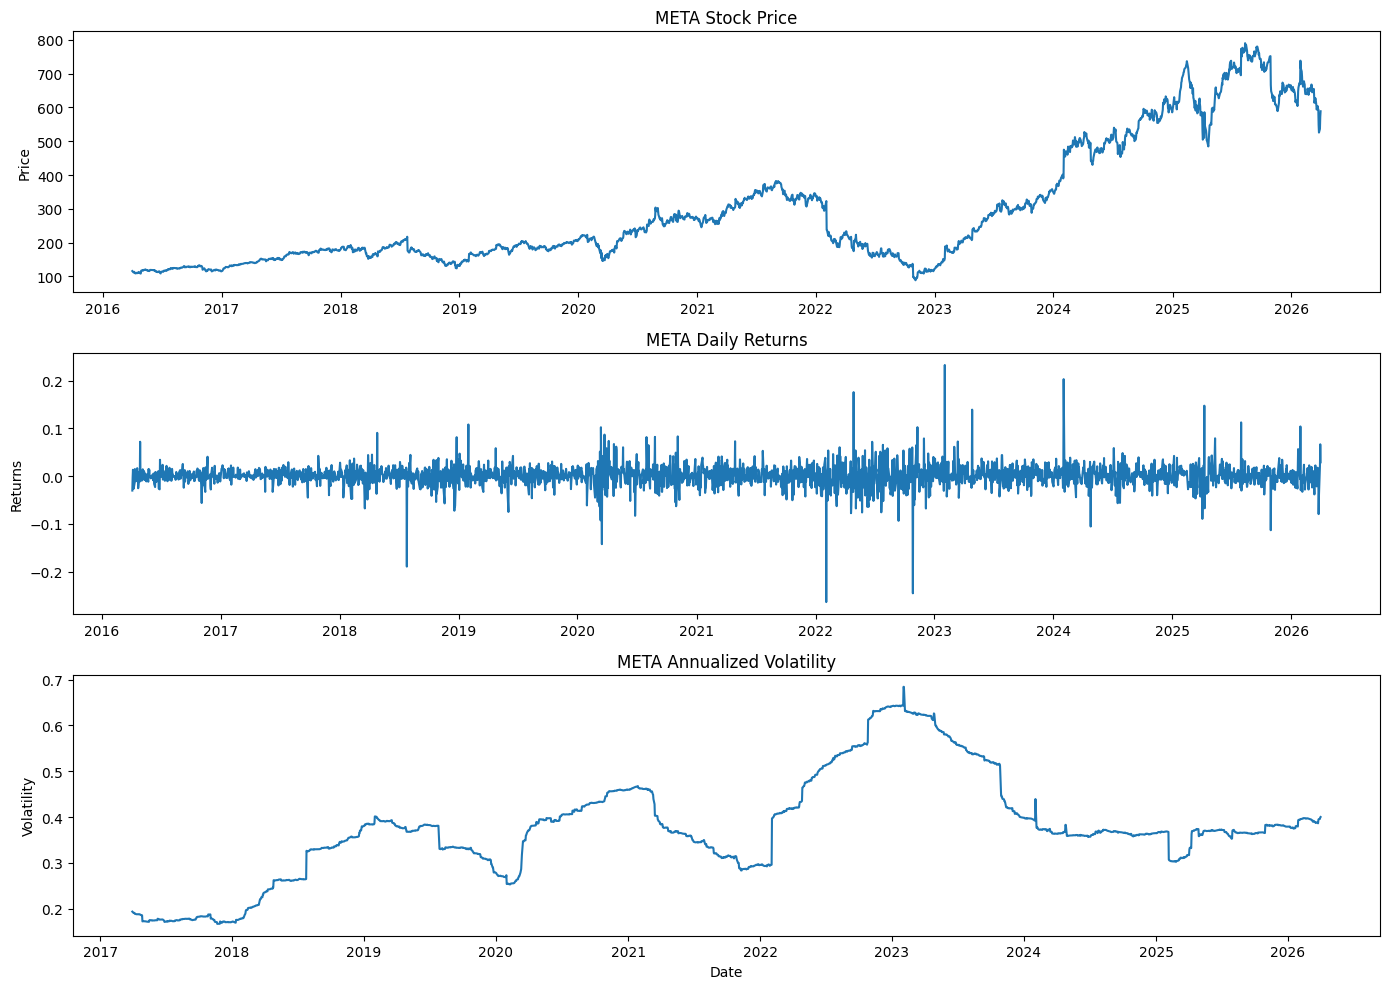

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "PriceHistory.xlsx"

# Read file with no header
df = pd.read_excel(file_path, header=None)

# Drop the title row(s) and keep only the actual data rows
# Try starting from row 1 first; if needed change to 2
# df = df.iloc[1:].copy()

# Assign the correct column names manually becuase I kept getting errors 
df.columns = [
    "Date",
    "Price",
    "CVol",
    "Change",
    "% Change",
    "% Return",
    "Total Return (Gross)",
    "Cumulative Return %",
    "Open",
    "High",
    "Low",
    "Cumulative Change %"
]

# Reset index
df.reset_index(drop=True, inplace=True)

# Convert data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Remove bad rows if any
df = df.dropna(subset=["Date", "Price"])

# Sort oldest to newest
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

# Calculate daily returns
df["Returns"] = df["Price"].pct_change()

# Calculate annualized volatility
df["Volatility"] = df["Returns"].rolling(window=252).std() * np.sqrt(252)

# Plot all 3
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(df.index, df["Price"])
plt.title("META Stock Price")
plt.ylabel("Price")

plt.subplot(3, 1, 2)
plt.plot(df.index, df["Returns"])
plt.title("META Daily Returns")
plt.ylabel("Returns")

plt.subplot(3, 1, 3)
plt.plot(df.index, df["Volatility"])
plt.title("META Annualized Volatility")
plt.ylabel("Volatility")
plt.xlabel("Date")

plt.tight_layout()
plt.show()